# 08 — Demo Apartments: Pre-Computed Outputs for the Pitch

**Goal:** Define 5 realistic Berlin apartments, run each through all 4 layers of the
RentSignal engine, and produce pitch-ready visuals.

**Layers per apartment:**
1. **PREDICT** — XGBoost market rent + prediction interval
2. **COMPLY** — Mietpreisbremse legal maximum (§556d BGB)
3. **EXPLAIN** — SHAP waterfall decomposition
4. **SIMULATE** — Renovation toggle (CATE + WTP + compliance shift + ROI/payback)

**Output:** `data/demo/demo_apartments.json` + pitch-ready PNG charts

---
## Step 0: Setup & Style

In [2]:
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import display

ROOT = Path(r"C:\Users\danny\OneDrive\Projects\MietOptimal")
sys.path.insert(0, str(ROOT))

%matplotlib inline

# ── Pitch-ready style ──────────────────────────────────────────────────────
COLORS = {
    'primary':    '#2563EB',   # blue-600
    'secondary':  '#7C3AED',   # violet-600
    'positive':   '#059669',   # emerald-600
    'negative':   '#DC2626',   # red-600
    'warning':    '#D97706',   # amber-600
    'neutral':    '#6B7280',   # gray-500
    'bg':         '#F9FAFB',   # gray-50
    'text':       '#111827',   # gray-900
    'light_blue': '#DBEAFE',   # blue-100
    'light_red':  '#FEE2E2',   # red-100
    'light_green':'#D1FAE5',   # emerald-100
}

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#E5E7EB',
    'axes.labelcolor': COLORS['text'],
    'text.color': COLORS['text'],
    'xtick.color': COLORS['neutral'],
    'ytick.color': COLORS['neutral'],
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.color': '#9CA3AF',
})

DEMO_DIR = ROOT / 'data' / 'demo'
DEMO_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output dir: {DEMO_DIR}")

Output dir: C:\Users\danny\OneDrive\Projects\MietOptimal\data\demo


In [3]:
import joblib
import shap

# Models
model = joblib.load(ROOT / 'models' / 'xgboost_rent.joblib')
encoder = joblib.load(ROOT / 'models' / 'feature_encoder.joblib')
explainer = joblib.load(ROOT / 'models' / 'shap_explainer.joblib')

with open(ROOT / 'models' / 'model_config.json') as f:
    config = json.load(f)

# CATE results
with open(ROOT / 'data' / 'processed' / 'matching_results.json') as f:
    cate_data = json.load(f)

# Conjoint WTP results
with open(ROOT / 'data' / 'processed' / 'conjoint_results.json') as f:
    wtp_data = json.load(f)

# Spatial features (for PLZ lookup)
df_osm = pd.read_csv(ROOT / 'data' / 'processed' / 'spatial_osm_features.csv')
df_sat = pd.read_csv(ROOT / 'data' / 'processed' / 'spatial_satellite_features.csv')
df_spatial = df_osm.merge(df_sat, on='plz', how='left')

# Mietspiegel reference
with open(ROOT / 'data' / 'reference' / 'mietspiegel_simplified.json') as f:
    mietspiegel = json.load(f)

# Compliance engine (standalone functions, not a class)
from backend.services.compliance_service import check_compliance, check_mietpreisbremse
from backend.models.compliance import ComplianceInput, ComplianceResult

print(f"Model loaded: {config['metrics']['r2']:.3f} R², {len(config['features'])} features")
print(f"Spatial data: {len(df_spatial)} PLZs")
print(f"CATE treatments: {list(cate_data['results'].keys())}")
print(f"WTP features: {list(wtp_data['wtp_results'].keys())}")

Model loaded: 0.749 R², 37 features
Spatial data: 190 PLZs
CATE treatments: ['hasKitchen', 'balcony', 'lift', 'garden']
WTP features: ['kitchen', 'balcony', 'elevator', 'garden', 'condition']


In [4]:
# ── Demo apartment definitions ──────────────────────────────────────────────
# Each dict maps to the 37 model features + metadata for compliance & narrative

DEMO_APARTMENTS = [
    {
        'id': 'kreuzberg_altbau',
        'name': 'Kreuzberg Altbau',
        'tagline': 'The Hidden Gem',
        'narrative': 'Underpriced — spatial premium not captured by the landlord',
        'plz': 10997,
        'current_rent_sqm': 10.50,
        # Apartment features
        'livingSpace': 78,
        'noRooms': 3,
        'yearConstructed': 1907,
        'floor': 3,
        'numberOfFloors': 5,
        'thermalChar': 145,
        'balcony': 1,
        'hasKitchen': 0,
        'lift': 0,
        'cellar': 1,
        'garden': 0,
        'newlyConst': 0,
        'condition': 'well_kept',
        'interiorQual': 'normal',
        'typeOfFlat': 'apartment',
        'heatingType': 'central_heating',
        'building_era': 'pre_1918',
        'bezirk': 'Kreuzberg',
    },
    {
        'id': 'wedding_altbau',
        'name': 'Wedding Altbau',
        'tagline': 'The Renovation Opportunity',
        'narrative': 'Renovation ROI analysis — kitchen yes, balcony no',
        'plz': 13353,
        'current_rent_sqm': 9.20,
        'livingSpace': 65,
        'noRooms': 2,
        'yearConstructed': 1955,
        'floor': 2,
        'numberOfFloors': 5,
        'thermalChar': 160,
        'balcony': 0,
        'hasKitchen': 0,
        'lift': 0,
        'cellar': 1,
        'garden': 0,
        'newlyConst': 0,
        'condition': 'well_kept',
        'interiorQual': 'normal',
        'typeOfFlat': 'apartment',
        'heatingType': 'district_heating',
        'building_era': '1950_1964',
        'bezirk': 'Wedding',
    },
    {
        'id': 'mitte_neubau',
        'name': 'Mitte Neubau',
        'tagline': 'The Premium New Build',
        'narrative': 'Correctly priced — Mietpreisbremse exempt (post-2014 Neubau)',
        'plz': 10117,
        'current_rent_sqm': 18.50,
        'livingSpace': 85,
        'noRooms': 3,
        'yearConstructed': 2019,
        'floor': 4,
        'numberOfFloors': 6,
        'thermalChar': 55,
        'balcony': 1,
        'hasKitchen': 1,
        'lift': 1,
        'cellar': 1,
        'garden': 0,
        'newlyConst': 1,
        'condition': 'first_time_use',
        'interiorQual': 'sophisticated',
        'typeOfFlat': 'apartment',
        'heatingType': 'floor_heating',
        'building_era': '2015_plus',
        'bezirk': 'Mitte',
    },
    {
        'id': 'lichtenberg_plattenbau',
        'name': 'Lichtenberg Plattenbau',
        'tagline': 'The Compliance Risk',
        'narrative': 'Overpriced — compliance risk flagged, weak spatial features',
        'plz': 10315,
        'current_rent_sqm': 12.80,
        'livingSpace': 58,
        'noRooms': 2,
        'yearConstructed': 1972,
        'floor': 8,
        'numberOfFloors': 11,
        'thermalChar': 130,
        'balcony': 1,
        'hasKitchen': 0,
        'lift': 1,
        'cellar': 1,
        'garden': 0,
        'newlyConst': 0,
        'condition': 'well_kept',
        'interiorQual': 'normal',
        'typeOfFlat': 'apartment',
        'heatingType': 'district_heating',
        'building_era': '1965_1972',
        'bezirk': 'Lichtenberg',
    },
    {
        'id': 'pberg_renovated',
        'name': 'Prenzlauer Berg Renovated',
        'tagline': 'The Gentrification Signal',
        'narrative': 'Post-modernization — category shift + spatial gentrification premium',
        'plz': 10435,
        'current_rent_sqm': 14.00,
        'livingSpace': 92,
        'noRooms': 4,
        'yearConstructed': 1905,
        'floor': 2,
        'numberOfFloors': 5,
        'thermalChar': 110,
        'balcony': 1,
        'hasKitchen': 1,
        'lift': 0,
        'cellar': 1,
        'garden': 1,
        'newlyConst': 0,
        'condition': 'fully_renovated',
        'interiorQual': 'sophisticated',
        'typeOfFlat': 'apartment',
        'heatingType': 'central_heating',
        'building_era': 'pre_1918',
        'bezirk': 'Berg',
    },
]

# Quick summary
summary = pd.DataFrame([{
    'Name': a['name'],
    'District': a['bezirk'],
    'PLZ': a['plz'],
    'Size': f"{a['livingSpace']}m²",
    'Year': a['yearConstructed'],
    'Rooms': a['noRooms'],
    'Kitchen': 'Yes' if a['hasKitchen'] else 'No',
    'Balcony': 'Yes' if a['balcony'] else 'No',
    'Lift': 'Yes' if a['lift'] else 'No',
    'Current Rent': f"€{a['current_rent_sqm']:.2f}/m²",
    'Story': a['tagline'],
} for a in DEMO_APARTMENTS])

print(summary.to_string(index=False))

                     Name    District   PLZ Size  Year  Rooms Kitchen Balcony Lift Current Rent                      Story
         Kreuzberg Altbau   Kreuzberg 10997 78m²  1907      3      No     Yes   No    €10.50/m²             The Hidden Gem
           Wedding Altbau     Wedding 13353 65m²  1955      2      No      No   No     €9.20/m² The Renovation Opportunity
             Mitte Neubau       Mitte 10117 85m²  2019      3     Yes     Yes  Yes    €18.50/m²      The Premium New Build
   Lichtenberg Plattenbau Lichtenberg 10315 58m²  1972      2      No     Yes  Yes    €12.80/m²        The Compliance Risk
Prenzlauer Berg Renovated        Berg 10435 92m²  1905      4     Yes     Yes   No    €14.00/m²  The Gentrification Signal


In [5]:
def prepare_features(apt, df_spatial):
    """Build a single-row DataFrame with all 37 model features."""
    row = {}
    
    # Numeric
    for f in config['numeric_features']:
        if f == 'sqm_per_room':
            row[f] = apt['livingSpace'] / max(apt['noRooms'], 1)
        else:
            row[f] = apt[f]
    
    # Binary
    for f in config['binary_features']:
        row[f] = apt[f]
    
    # Categorical (encode)
    cat_values = [apt[f] for f in config['categorical_features']]
    cat_encoded = encoder.transform([cat_values])[0]
    for f, val in zip(config['categorical_features'], cat_encoded):
        row[f] = val
    
    # Spatial (PLZ lookup)
    plz_row = df_spatial[df_spatial['plz'] == apt['plz']]
    if len(plz_row) > 0:
        plz_row = plz_row.iloc[0]
        for f in config['osm_features'] + config['satellite_features']:
            row[f] = plz_row.get(f, 0)
    else:
        for f in config['osm_features'] + config['satellite_features']:
            row[f] = 0
    
    return pd.DataFrame([row])[config['features']]


def run_compliance(apt):
    """Run Mietpreisbremse check using standalone functions."""
    try:
        inp = ComplianceInput(
            district=apt['bezirk'],
            living_space_sqm=apt['livingSpace'],
            building_year=apt['yearConstructed'],
            current_rent_per_sqm=apt.get('current_rent_sqm'),
            has_fitted_kitchen=bool(apt.get('hasKitchen')),
            has_balcony=bool(apt.get('balcony')),
            has_elevator=bool(apt.get('lift')),
            has_basement_storage=bool(apt.get('cellar')),
            has_modern_heating=apt.get('heatingType') in ('floor_heating', 'heat_pump'),
        )
        return check_compliance(inp)
    except Exception as e:
        print(f"  Compliance error for {apt['name']}: {e}")
        return None


def compute_renovation_sim(apt):
    """Compute renovation simulator outputs for all 4 toggles."""
    RENT_INFLATION = wtp_data['rent_inflation_factor']  # 1.378
    RENOVATION_COSTS = {
        'hasKitchen': {'cost_eur': 15000, 'label': 'Modern Kitchen'},
        'balcony':    {'cost_eur': 8000,  'label': 'Small Balcony'},
        'lift':       {'cost_eur': 45000, 'label': 'Elevator'},
        'garden':     {'cost_eur': 5000,  'label': 'Garden Access'},
    }
    
    WTP_MAP = {
        'hasKitchen': 'kitchen',
        'balcony': 'balcony',
        'lift': 'elevator',
        'garden': 'garden',
    }
    
    results = {}
    for treatment, info in RENOVATION_COSTS.items():
        # Skip if apartment already has this feature
        if apt.get(treatment, 0) == 1:
            results[treatment] = {'already_has': True, 'label': info['label']}
            continue
        
        # CATE (inflation-adjusted)
        cate_raw = cate_data['results'][treatment]['att']
        cate_adj = cate_raw * RENT_INFLATION
        cate_ci = [
            cate_data['results'][treatment]['ci_low'] * RENT_INFLATION,
            cate_data['results'][treatment]['ci_high'] * RENT_INFLATION,
        ]
        
        # Conjoint WTP
        wtp_key = WTP_MAP[treatment]
        wtp_entry = list(wtp_data['wtp_results'].get(wtp_key, {}).values())
        wtp_sqm = wtp_entry[0]['wtp_eur_sqm'] if wtp_entry else 0
        
        # Combined estimate (average of CATE and WTP)
        combined = (cate_adj + wtp_sqm) / 2
        
        # Monthly uplift (EUR)
        monthly_uplift = combined * apt['livingSpace']
        annual_uplift = monthly_uplift * 12
        
        # Payback
        payback_months = info['cost_eur'] / monthly_uplift if monthly_uplift > 0 else float('inf')
        
        # Legal passthrough (§559: 8% of cost per year)
        legal_monthly = (info['cost_eur'] * 0.08) / 12
        legal_sqm = legal_monthly / apt['livingSpace']
        
        results[treatment] = {
            'already_has': False,
            'label': info['label'],
            'cost_eur': info['cost_eur'],
            'cate_sqm': round(cate_adj, 2),
            'cate_ci': [round(c, 2) for c in cate_ci],
            'wtp_sqm': round(wtp_sqm, 2),
            'combined_sqm': round(combined, 2),
            'monthly_uplift_eur': round(monthly_uplift, 0),
            'annual_uplift_eur': round(annual_uplift, 0),
            'payback_months': round(payback_months, 0) if payback_months != float('inf') else None,
            'legal_passthrough_sqm': round(legal_sqm, 2),
            'roi_annual_pct': round((annual_uplift / info['cost_eur']) * 100, 1) if annual_uplift > 0 else 0,
        }
    
    return results


# ── Run the full pipeline ───────────────────────────────────────────────────
results = []

for apt in DEMO_APARTMENTS:
    print(f"\n{'='*60}")
    print(f"  {apt['name']}  ({apt['bezirk']}, {apt['plz']})")
    print(f"{'='*60}")
    
    # 1. Predict
    X = prepare_features(apt, df_spatial)
    pred = model.predict(X)[0]
    print(f"  Market prediction:  \u20ac{pred:.2f}/m\u00b2")
    print(f"  Current rent:       \u20ac{apt['current_rent_sqm']:.2f}/m\u00b2")
    gap = pred - apt['current_rent_sqm']
    gap_pct = (gap / apt['current_rent_sqm']) * 100
    status = 'UNDERPRICED' if gap > 0.5 else 'OVERPRICED' if gap < -0.5 else 'FAIRLY PRICED'
    print(f"  Gap:                \u20ac{gap:+.2f}/m\u00b2 ({gap_pct:+.1f}%) \u2192 {status}")
    
    # 2. SHAP
    shap_values = explainer.shap_values(X)
    base_value = explainer.expected_value
    
    # 3. Compliance
    comp = run_compliance(apt)
    if comp:
        legal_max = comp.mietpreisbremse.legal_max_rent_per_sqm
        print(f"  Legal max:          \u20ac{legal_max:.2f}/m\u00b2")
        print(f"  Compliant:          {comp.is_compliant}")
        if comp.mietpreisbremse.is_exempt:
            print(f"  Exemption:          {comp.mietpreisbremse.exemption_reason_en}")
    
    # 4. Renovation simulator
    reno = compute_renovation_sim(apt)
    print(f"  \n  Renovation Simulator:")
    for treatment, r in reno.items():
        if r.get('already_has'):
            print(f"    {r['label']:20s}  Already has")
        else:
            pb = f"{r['payback_months']:.0f}mo" if r['payback_months'] else 'N/A'
            print(f"    {r['label']:20s}  +\u20ac{r['combined_sqm']:.2f}/m\u00b2  Cost: \u20ac{r['cost_eur']:,}  Payback: {pb}  ROI: {r['roi_annual_pct']}%/yr")
    
    # Store
    results.append({
        'apartment': apt,
        'prediction': {
            'rent_sqm': round(pred, 2),
            'current_rent_sqm': apt['current_rent_sqm'],
            'gap_sqm': round(gap, 2),
            'gap_pct': round(gap_pct, 1),
            'status': status,
        },
        'shap': {
            'base_value': round(float(base_value), 2),
            'values': {f: round(float(v), 4) for f, v in zip(config['features'], shap_values[0])},
        },
        'compliance': {
            'legal_max_sqm': round(comp.mietpreisbremse.legal_max_rent_per_sqm, 2) if comp else None,
            'is_compliant': comp.is_compliant if comp else None,
            'mietspiegel_mid': round(comp.mietpreisbremse.mietspiegel.adjusted_mid, 2) if comp else None,
            'is_exempt': comp.mietpreisbremse.is_exempt if comp else None,
            'exemption': comp.mietpreisbremse.exemption_reason_en if comp and comp.mietpreisbremse.is_exempt else None,
        },
        'renovation': reno,
    })


  Kreuzberg Altbau  (Kreuzberg, 10997)
  Market prediction:  €11.89/m²
  Current rent:       €10.50/m²
  Gap:                €+1.39/m² (+13.3%) → UNDERPRICED
  Legal max:          €8.50/m²
  Compliant:          False
  
  Renovation Simulator:
    Modern Kitchen        +€4.07/m²  Cost: €15,000  Payback: 47mo  ROI: 25.4%/yr
    Small Balcony         Already has
    Elevator              +€1.45/m²  Cost: €45,000  Payback: 397mo  ROI: 3.0%/yr
    Garden Access         +€0.97/m²  Cost: €5,000  Payback: 66mo  ROI: 18.2%/yr

  Wedding Altbau  (Wedding, 13353)
  Market prediction:  €11.79/m²
  Current rent:       €9.20/m²
  Gap:                €+2.59/m² (+28.1%) → UNDERPRICED
  Legal max:          €8.14/m²
  Compliant:          False
  
  Renovation Simulator:
    Modern Kitchen        +€4.07/m²  Cost: €15,000  Payback: 57mo  ROI: 21.2%/yr
    Small Balcony         +€0.01/m²  Cost: €8,000  Payback: 17478mo  ROI: 0.1%/yr
    Elevator              +€1.45/m²  Cost: €45,000  Payback: 476mo  ROI:

c:\Users\danny\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(
c:\Users\danny\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(
c:\Users\danny\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(
c:\Users\danny\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


  Legal max:          €7.81/m²
  Compliant:          False
  
  Renovation Simulator:
    Modern Kitchen        +€4.07/m²  Cost: €15,000  Payback: 64mo  ROI: 18.9%/yr
    Small Balcony         Already has
    Elevator              Already has
    Garden Access         +€0.97/m²  Cost: €5,000  Payback: 89mo  ROI: 13.5%/yr

  Prenzlauer Berg Renovated  (Berg, 10435)
  Market prediction:  €16.59/m²
  Current rent:       €14.00/m²
  Gap:                €+2.59/m² (+18.5%) → UNDERPRICED
  Legal max:          €8.46/m²
  Compliant:          False
  
  Renovation Simulator:
    Modern Kitchen        Already has
    Small Balcony         Already has
    Elevator              +€1.45/m²  Cost: €45,000  Payback: 336mo  ROI: 3.6%/yr
    Garden Access         Already has


c:\Users\danny\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


---
## Step 4: Pitch-Ready Visuals

### 4a: Overview Dashboard — All 5 Apartments

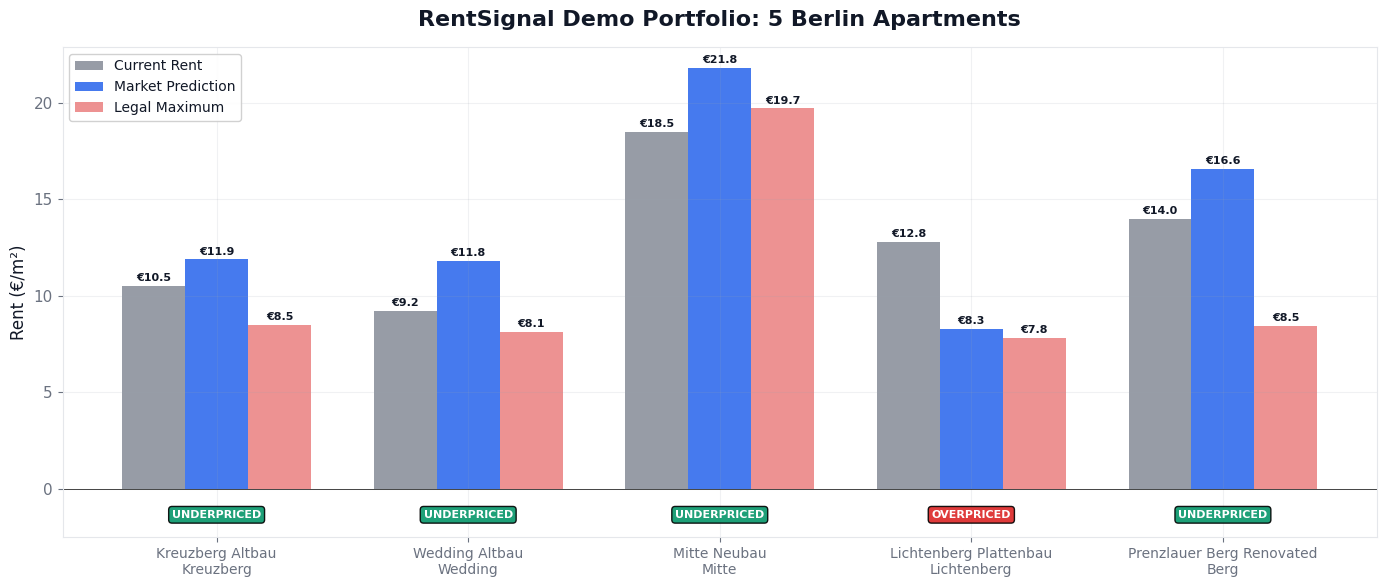

Saved: C:\Users\danny\OneDrive\Projects\MietOptimal\data\demo\demo_overview.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

names = [r['apartment']['name'] for r in results]
current = [r['prediction']['current_rent_sqm'] for r in results]
predicted = [r['prediction']['rent_sqm'] for r in results]
legal_max = [r['compliance']['legal_max_sqm'] or r['prediction']['rent_sqm'] for r in results]

x = np.arange(len(names))
width = 0.25

bars1 = ax.bar(x - width, current, width, label='Current Rent', color=COLORS['neutral'], alpha=0.7)
bars2 = ax.bar(x, predicted, width, label='Market Prediction', color=COLORS['primary'], alpha=0.85)
bars3 = ax.bar(x + width, legal_max, width, label='Legal Maximum', color=COLORS['negative'], alpha=0.5)

# Value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.15,
                f'\u20ac{h:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Status badges
for i, r in enumerate(results):
    status = r['prediction']['status']
    color = COLORS['positive'] if status == 'UNDERPRICED' else COLORS['negative'] if status == 'OVERPRICED' else COLORS['neutral']
    ax.text(x[i], -1.5, status, ha='center', fontsize=8, fontweight='bold',
            color='white', bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.9))

ax.set_xticks(x)
ax.set_xticklabels([f"{n}\n{r['apartment']['bezirk']}" for n, r in zip(names, results)], fontsize=10)
ax.set_ylabel('Rent (\u20ac/m\u00b2)', fontsize=12)
ax.set_title('RentSignal Demo Portfolio: 5 Berlin Apartments', fontsize=16, pad=15)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.set_ylim(bottom=-2.5)
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(str(DEMO_DIR / 'demo_overview.png'), dpi=200, bbox_inches='tight')
display(fig)
plt.close(fig)
print(f"Saved: {DEMO_DIR / 'demo_overview.png'}")

### 4b: SHAP Waterfall — Wedding Apartment (The Demo Star)

c:\Users\danny\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


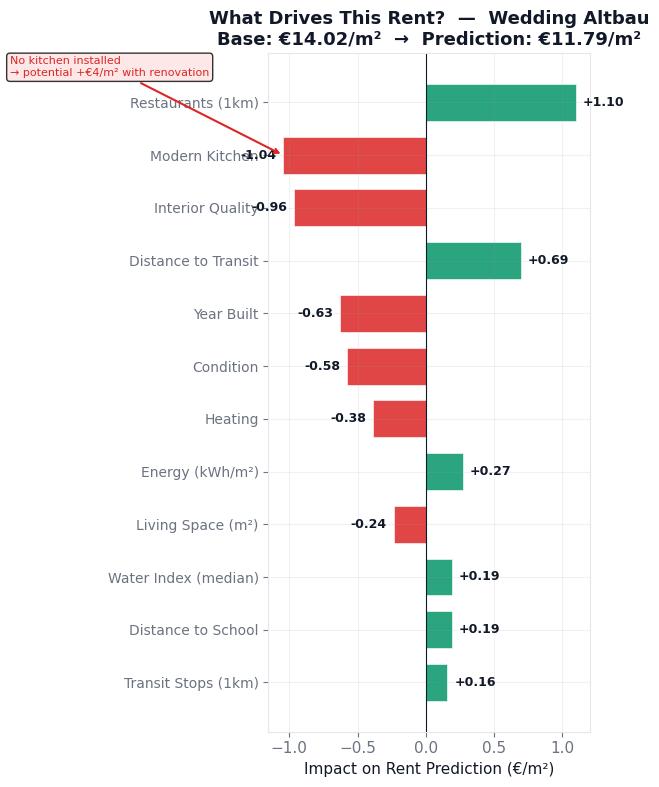

Saved: C:\Users\danny\OneDrive\Projects\MietOptimal\data\demo\shap_wedding.png


In [7]:
# Wedding apartment SHAP waterfall — the demo star
wedding_idx = 1  # Wedding Altbau
wedding_result = results[wedding_idx]
wedding_apt = DEMO_APARTMENTS[wedding_idx]

# Prepare SHAP for waterfall
X_wedding = prepare_features(wedding_apt, df_spatial)
shap_vals = explainer.shap_values(X_wedding)[0]
base = float(explainer.expected_value)

# Get top 12 features by absolute SHAP
feat_shap = list(zip(config['features'], shap_vals, X_wedding.iloc[0]))
feat_shap.sort(key=lambda x: abs(x[1]), reverse=True)
top_n = 12
top_features = feat_shap[:top_n]

# Human-readable feature names
FEATURE_LABELS = {
    'livingSpace': 'Living Space (m\u00b2)',
    'noRooms': 'Rooms',
    'yearConstructed': 'Year Built',
    'floor': 'Floor',
    'numberOfFloors': 'Building Floors',
    'thermalChar': 'Energy (kWh/m\u00b2)',
    'sqm_per_room': 'm\u00b2 per Room',
    'balcony': 'Balcony',
    'hasKitchen': 'Modern Kitchen',
    'lift': 'Elevator',
    'cellar': 'Cellar',
    'garden': 'Garden',
    'newlyConst': 'New Construction',
    'condition': 'Condition',
    'interiorQual': 'Interior Quality',
    'typeOfFlat': 'Flat Type',
    'heatingType': 'Heating',
    'building_era': 'Building Era',
    'bezirk': 'District',
    'count_food_1000m': 'Restaurants (1km)',
    'count_food_500m': 'Restaurants (500m)',
    'count_shop_1000m': 'Shops (1km)',
    'count_shop_500m': 'Shops (500m)',
    'count_transit_1000m': 'Transit Stops (1km)',
    'dist_transit_m': 'Distance to Transit',
    'dist_park_m': 'Distance to Park',
    'dist_water_m': 'Distance to Water',
    'dist_school_m': 'Distance to School',
    'ndvi_mean': 'Vegetation (NDVI)',
    'ndvi_std': 'Vegetation Variation',
    'ndvi_median': 'Vegetation (median)',
    'ndwi_mean': 'Water Index (NDWI)',
    'ndwi_std': 'Water Variation',
    'ndwi_median': 'Water Index (median)',
    'ndbi_mean': 'Built-up (NDBI)',
    'ndbi_std': 'Built-up Variation',
    'ndbi_median': 'Built-up (median)',
}

# Custom waterfall chart
fig, ax = plt.subplots(figsize=(10, 8))

labels = [FEATURE_LABELS.get(f, f) for f, _, _ in reversed(top_features)]
values = [float(v) for _, v, _ in reversed(top_features)]
colors = [COLORS['positive'] if v > 0 else COLORS['negative'] for v in values]

y_pos = np.arange(len(labels))
bars = ax.barh(y_pos, values, color=colors, alpha=0.85, height=0.7, edgecolor='white', linewidth=0.5)

# Value labels
for i, (bar, val) in enumerate(zip(bars, values)):
    offset = 0.05 if val >= 0 else -0.05
    ax.text(val + offset, i, f'{val:+.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Impact on Rent Prediction (\u20ac/m\u00b2)', fontsize=11)
ax.set_title(f'What Drives This Rent?  \u2014  {wedding_apt["name"]}\n'
             f'Base: \u20ac{base:.2f}/m\u00b2  \u2192  Prediction: \u20ac{wedding_result["prediction"]["rent_sqm"]:.2f}/m\u00b2',
             fontsize=13)
ax.axvline(x=0, color=COLORS['text'], linewidth=0.8)

# Add annotation for kitchen
kitchen_idx = next((i for i, (f, _, _) in enumerate(reversed(top_features)) if f == 'hasKitchen'), None)
if kitchen_idx is not None:
    ax.annotate('No kitchen installed\n\u2192 potential +\u20ac4/m\u00b2 with renovation',
                xy=(values[kitchen_idx], kitchen_idx),
                xytext=(values[kitchen_idx] - 2, kitchen_idx + 1.5),
                fontsize=8, color=COLORS['negative'],
                arrowprops=dict(arrowstyle='->', color=COLORS['negative'], lw=1.5),
                bbox=dict(boxstyle='round,pad=0.3', facecolor=COLORS['light_red'], alpha=0.8))

plt.tight_layout()
plt.savefig(str(DEMO_DIR / 'shap_wedding.png'), dpi=200, bbox_inches='tight')
display(fig)
plt.close(fig)
print(f"Saved: {DEMO_DIR / 'shap_wedding.png'}")

### 4c: Renovation ROI Comparison — Wedding Apartment

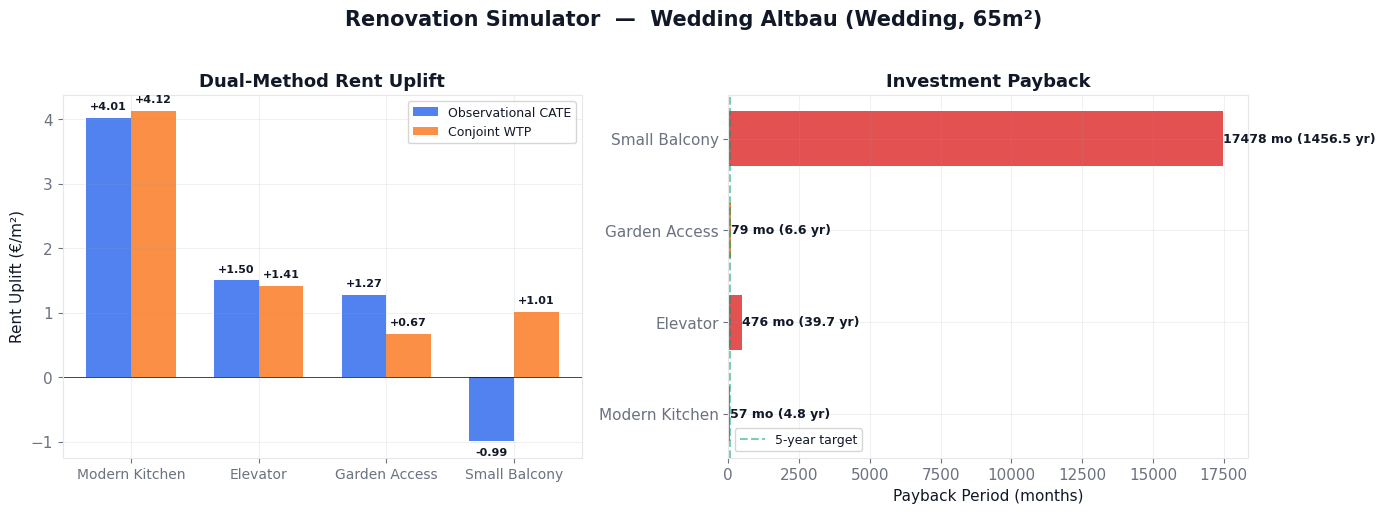

Saved: C:\Users\danny\OneDrive\Projects\MietOptimal\data\demo\renovation_wedding.png


In [8]:
# Renovation ROI chart — the "don't build the balcony" moment
wedding_reno = results[wedding_idx]['renovation']

# Filter to renovations the apartment doesn't already have
reno_items = [(k, v) for k, v in wedding_reno.items() if not v.get('already_has', False)]
reno_items.sort(key=lambda x: x[1].get('combined_sqm', 0), reverse=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Rent uplift (combined CATE + WTP)
labels = [v['label'] for _, v in reno_items]
uplifts = [v['combined_sqm'] for _, v in reno_items]
cate_vals = [v['cate_sqm'] for _, v in reno_items]
wtp_vals = [v['wtp_sqm'] for _, v in reno_items]
colors_left = [COLORS['positive'] if u > 0 else COLORS['negative'] for u in uplifts]

x = np.arange(len(labels))
w = 0.35
ax1.bar(x - w/2, cate_vals, w, label='Observational CATE', color=COLORS['primary'], alpha=0.8)
ax1.bar(x + w/2, wtp_vals, w, label='Conjoint WTP', color='#F97316', alpha=0.8)

for i, (c, wt) in enumerate(zip(cate_vals, wtp_vals)):
    ax1.text(i - w/2, c + 0.1 * (1 if c >= 0 else -1), f'{c:+.2f}',
            ha='center', va='bottom' if c >= 0 else 'top', fontsize=8, fontweight='bold')
    ax1.text(i + w/2, wt + 0.1 * (1 if wt >= 0 else -1), f'{wt:+.2f}',
            ha='center', va='bottom' if wt >= 0 else 'top', fontsize=8, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=10)
ax1.set_ylabel('Rent Uplift (\u20ac/m\u00b2)', fontsize=11)
ax1.set_title('Dual-Method Rent Uplift', fontsize=13)
ax1.legend(fontsize=9)
ax1.axhline(y=0, color='black', linewidth=0.5)

# Right: Payback period
paybacks = []
pb_colors = []
for _, v in reno_items:
    pb = v.get('payback_months')
    if pb and pb > 0:
        paybacks.append(pb)
        pb_colors.append(COLORS['positive'] if pb < 60 else COLORS['warning'] if pb < 120 else COLORS['negative'])
    else:
        paybacks.append(0)
        pb_colors.append(COLORS['neutral'])

bars2 = ax2.barh(labels, paybacks, color=pb_colors, alpha=0.8, height=0.6)

for i, (bar, pb) in enumerate(zip(bars2, paybacks)):
    if pb > 0:
        years = pb / 12
        ax2.text(pb + 2, i, f'{pb:.0f} mo ({years:.1f} yr)', va='center', fontsize=9, fontweight='bold')

ax2.set_xlabel('Payback Period (months)', fontsize=11)
ax2.set_title('Investment Payback', fontsize=13)
ax2.axvline(x=60, color=COLORS['positive'], linestyle='--', alpha=0.5, label='5-year target')
ax2.legend(fontsize=9)

fig.suptitle(f'Renovation Simulator  \u2014  {wedding_apt["name"]} ({wedding_apt["bezirk"]}, {wedding_apt["livingSpace"]}m\u00b2)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(str(DEMO_DIR / 'renovation_wedding.png'), dpi=200, bbox_inches='tight')
display(fig)
plt.close(fig)
print(f"Saved: {DEMO_DIR / 'renovation_wedding.png'}")

### 4d: Compliance Risk — Lichtenberg Overpriced

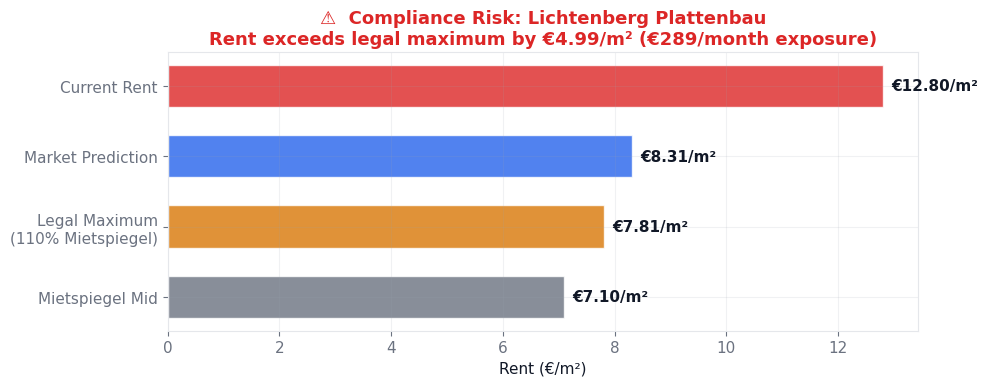

Saved: C:\Users\danny\OneDrive\Projects\MietOptimal\data\demo\compliance_lichtenberg.png


In [9]:
# Compliance risk visualization for Lichtenberg (overpriced)
lberg_idx = 3
lberg = results[lberg_idx]

fig, ax = plt.subplots(figsize=(10, 4))

legal_max = lberg['compliance']['legal_max_sqm'] or 0
current = lberg['prediction']['current_rent_sqm']
predicted = lberg['prediction']['rent_sqm']
mietspiegel = lberg['compliance'].get('mietspiegel_mid') or 0

# Horizontal gauge
categories = ['Mietspiegel Mid', 'Legal Maximum\n(110% Mietspiegel)', 'Market Prediction', 'Current Rent']
values = [mietspiegel, legal_max, predicted, current]
bar_colors = [COLORS['neutral'], COLORS['warning'], COLORS['primary'], 
              COLORS['negative'] if current > legal_max else COLORS['positive']]

y_pos = np.arange(len(categories))
bars = ax.barh(y_pos, values, color=bar_colors, alpha=0.8, height=0.6, edgecolor='white')

for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(val + 0.15, i, f'\u20ac{val:.2f}/m\u00b2', va='center', fontsize=11, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(categories, fontsize=11)
ax.set_xlabel('Rent (\u20ac/m\u00b2)', fontsize=11)

# Risk zone
if current > legal_max:
    excess = current - legal_max
    excess_monthly = excess * DEMO_APARTMENTS[lberg_idx]['livingSpace']
    ax.set_title(f'\u26a0\ufe0f  Compliance Risk: {DEMO_APARTMENTS[lberg_idx]["name"]}\n'
                 f'Rent exceeds legal maximum by \u20ac{excess:.2f}/m\u00b2 (\u20ac{excess_monthly:.0f}/month exposure)',
                 fontsize=13, color=COLORS['negative'])
else:
    ax.set_title(f'{DEMO_APARTMENTS[lberg_idx]["name"]} — Compliance Check', fontsize=13)

plt.tight_layout()
plt.savefig(str(DEMO_DIR / 'compliance_lichtenberg.png'), dpi=200, bbox_inches='tight')
display(fig)
plt.close(fig)
print(f"Saved: {DEMO_DIR / 'compliance_lichtenberg.png'}")

### 4e: The Money Slide — Kitchen vs Balcony ROI

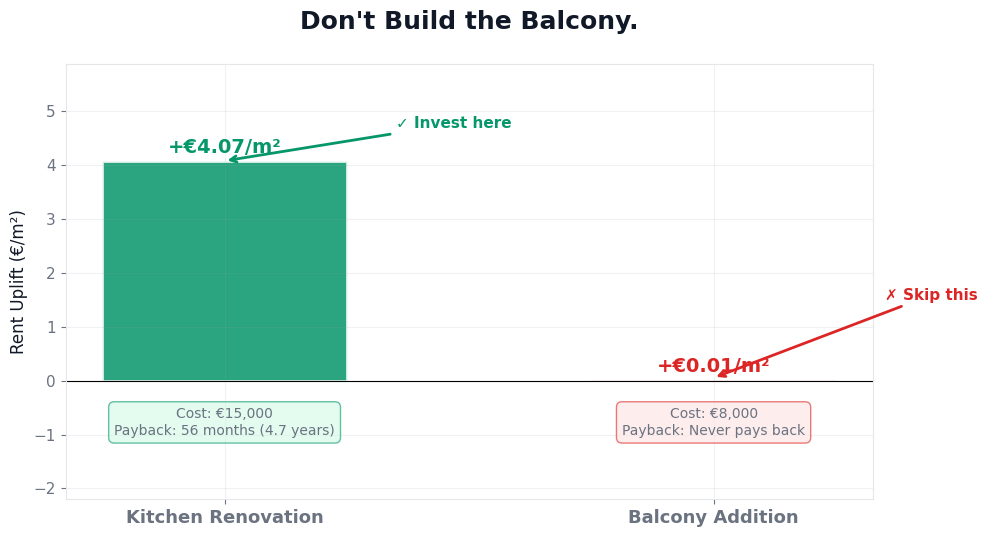

Saved: C:\Users\danny\OneDrive\Projects\MietOptimal\data\demo\kitchen_vs_balcony.png


In [12]:
# The punchline chart: Kitchen vs Balcony across all apartments that lack them

# Find apartments that lack kitchen or balcony
kitchen_data = []
balcony_data = []

for r in results:
    apt = r['apartment']
    reno = r['renovation']
    
    if 'hasKitchen' in reno and not reno['hasKitchen'].get('already_has'):
        kitchen_data.append({
            'name': apt['name'],
            'uplift': reno['hasKitchen']['combined_sqm'],
            'payback': reno['hasKitchen'].get('payback_months') or 0,
            'roi': reno['hasKitchen']['roi_annual_pct'],
        })
    
    if 'balcony' in reno and not reno['balcony'].get('already_has'):
        balcony_data.append({
            'name': apt['name'],
            'uplift': reno['balcony']['combined_sqm'],
            'payback': reno['balcony'].get('payback_months') or 0,
            'roi': reno['balcony']['roi_annual_pct'],
        })

fig, ax = plt.subplots(figsize=(10, 5.5))

# Average values
k_uplift = np.mean([d['uplift'] for d in kitchen_data]) if kitchen_data else 0
b_uplift = np.mean([d['uplift'] for d in balcony_data]) if balcony_data else 0

# Payback: filter out extreme outliers for display
k_paybacks = [d['payback'] for d in kitchen_data if 0 < d['payback'] < 999]
b_paybacks = [d['payback'] for d in balcony_data if 0 < d['payback'] < 999]
k_payback = np.mean(k_paybacks) if k_paybacks else 0
b_payback = np.mean(b_paybacks) if b_paybacks else 0

categories = ['Kitchen Renovation', 'Balcony Addition']
uplifts = [k_uplift, b_uplift]
costs = [15000, 8000]

bar_colors = [COLORS['positive'], COLORS['negative'] if b_uplift < 1 else COLORS['warning']]

x = np.arange(2)
bars = ax.bar(x, uplifts, width=0.5, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=2)

for i, (bar, u, cost) in enumerate(zip(bars, uplifts, costs)):
    # Uplift label
    ax.text(i, u + 0.15, f'+\u20ac{u:.2f}/m\u00b2', ha='center', fontsize=14, fontweight='bold',
            color=bar_colors[i])

# Details boxes at the bottom
k_pb_text = f'{k_payback:.0f} months ({k_payback/12:.1f} years)' if k_payback > 0 else 'N/A'
b_pb_text = f'{b_payback:.0f} months ({b_payback/12:.1f} years)' if b_payback > 0 else 'Never pays back'

ax.text(0, -1.0, f'Cost: \u20ac{costs[0]:,}\nPayback: {k_pb_text}', ha='center', fontsize=10,
        color=COLORS['neutral'],
        bbox=dict(boxstyle='round,pad=0.4', facecolor=COLORS['light_green'], edgecolor=COLORS['positive'], alpha=0.6))
ax.text(1, -1.0, f'Cost: \u20ac{costs[1]:,}\nPayback: {b_pb_text}', ha='center', fontsize=10,
        color=COLORS['neutral'],
        bbox=dict(boxstyle='round,pad=0.4', facecolor=COLORS['light_red'], edgecolor=COLORS['negative'], alpha=0.6))

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=13, fontweight='bold')
ax.set_ylabel('Rent Uplift (\u20ac/m\u00b2)', fontsize=12)
ax.set_title("Don't Build the Balcony.", fontsize=18, fontweight='bold', pad=25)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylim(bottom=-2.2, top=k_uplift + 1.8)

# Verdict annotations — positioned below the title, not overlapping
ax.annotate('\u2713 Invest here', xy=(0, k_uplift), xytext=(0.35, k_uplift + 0.6),
            fontsize=11, fontweight='bold', color=COLORS['positive'],
            arrowprops=dict(arrowstyle='->', color=COLORS['positive'], lw=2))

if b_uplift < 1:
    ax.annotate('\u2717 Skip this', xy=(1, max(b_uplift, 0.05)), xytext=(1.35, 1.5),
                fontsize=11, fontweight='bold', color=COLORS['negative'],
                arrowprops=dict(arrowstyle='->', color=COLORS['negative'], lw=2))

plt.tight_layout()
plt.savefig(str(DEMO_DIR / 'kitchen_vs_balcony.png'), dpi=200, bbox_inches='tight')
display(fig)
plt.close(fig)
print(f"Saved: {DEMO_DIR / 'kitchen_vs_balcony.png'}")

---
## Step 5: Export All Results

In [14]:
# Clean results for JSON export (remove non-serializable items)

def make_serializable(obj):
    """Recursively convert numpy types to Python native for JSON."""
    if isinstance(obj, dict):
        return {k: make_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [make_serializable(v) for v in obj]
    elif isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

export = {
    'generated': '2026-03-15',
    'model_version': 'v3_spatial',
    'model_r2': config['metrics']['r2'],
    'n_features': len(config['features']),
    'apartments': []
}

for r in results:
    apt_export = {
        'id': r['apartment']['id'],
        'name': r['apartment']['name'],
        'tagline': r['apartment']['tagline'],
        'narrative': r['apartment']['narrative'],
        'district': r['apartment']['bezirk'],
        'plz': r['apartment']['plz'],
        'specs': {
            'living_space_sqm': r['apartment']['livingSpace'],
            'rooms': r['apartment']['noRooms'],
            'year_built': r['apartment']['yearConstructed'],
            'floor': r['apartment']['floor'],
            'building_floors': r['apartment']['numberOfFloors'],
            'has_kitchen': bool(r['apartment']['hasKitchen']),
            'has_balcony': bool(r['apartment']['balcony']),
            'has_elevator': bool(r['apartment']['lift']),
            'has_garden': bool(r['apartment']['garden']),
            'condition': r['apartment']['condition'],
        },
        'prediction': r['prediction'],
        'compliance': r['compliance'],
        'shap_top_features': dict(
            sorted(r['shap']['values'].items(), key=lambda x: abs(x[1]), reverse=True)[:10]
        ),
        'shap_base_value': r['shap']['base_value'],
        'renovation': r['renovation'],
    }
    export['apartments'].append(apt_export)

export = make_serializable(export)

output_path = DEMO_DIR / 'demo_apartments.json'
with open(output_path, 'w') as f:
    json.dump(export, f, indent=2)

print(f'Saved: {output_path}')
print(f'\nApartments: {len(export["apartments"])}')
for apt in export['apartments']:
    legal = apt['compliance']['legal_max_sqm']
    legal_str = f"\u20ac{legal}/m\u00b2" if legal else 'EXEMPT'
    print(f"  {apt['name']:30s}  Pred: \u20ac{apt['prediction']['rent_sqm']:.2f}/m\u00b2  "
          f"Status: {apt['prediction']['status']}  "
          f"Legal: {legal_str}")

Saved: C:\Users\danny\OneDrive\Projects\MietOptimal\data\demo\demo_apartments.json

Apartments: 5
  Kreuzberg Altbau                Pred: €11.89/m²  Status: UNDERPRICED  Legal: €8.5/m²
  Wedding Altbau                  Pred: €11.79/m²  Status: UNDERPRICED  Legal: €8.14/m²
  Mitte Neubau                    Pred: €21.82/m²  Status: UNDERPRICED  Legal: €19.72/m²
  Lichtenberg Plattenbau          Pred: €8.31/m²  Status: OVERPRICED  Legal: €7.81/m²
  Prenzlauer Berg Renovated       Pred: €16.59/m²  Status: UNDERPRICED  Legal: €8.46/m²


---
## Step 6: Speaker Notes

Pre-written demo script for each apartment.

In [15]:
# Generate speaker notes from results
for r in results:
    apt = r['apartment']
    pred = r['prediction']
    comp = r['compliance']
    reno = r['renovation']
    
    print(f"\n{'='*70}")
    print(f"  SPEAKER NOTES: {apt['name']}  ({apt['tagline']})")
    print(f"{'='*70}")
    
    # Opening
    print(f"\n  \"Here's a {apt['livingSpace']}m\u00b2 {apt['building_era'].replace('_', '-')} "
          f"apartment in {apt['bezirk']}.\"")
    
    # Prediction insight
    if pred['status'] == 'UNDERPRICED':
        monthly_loss = pred['gap_sqm'] * apt['livingSpace']
        annual_loss = monthly_loss * 12
        print(f"\n  \"The landlord charges \u20ac{pred['current_rent_sqm']:.2f}/m\u00b2, but our model says "
              f"the market rate is \u20ac{pred['rent_sqm']:.2f}/m\u00b2. That's \u20ac{monthly_loss:.0f}/month "
              f"left on the table — \u20ac{annual_loss:.0f} per year.\"")
    elif pred['status'] == 'OVERPRICED':
        print(f"\n  \"The landlord charges \u20ac{pred['current_rent_sqm']:.2f}/m\u00b2, but our model says "
              f"\u20ac{pred['rent_sqm']:.2f}/m\u00b2. This apartment is overpriced by {abs(pred['gap_pct']):.0f}%.\"")
    else:
        print(f"\n  \"At \u20ac{pred['current_rent_sqm']:.2f}/m\u00b2, this is fairly priced — "
              f"our model confirms at \u20ac{pred['rent_sqm']:.2f}/m\u00b2.\"")
    
    # Compliance
    if comp.get('exemption'):
        print(f"\n  \"And notice: this is a post-2014 new build — the Mietpreisbremse doesn't apply. "
              f"The landlord can charge market rate.\"")
    elif comp.get('legal_max_sqm'):
        if pred['current_rent_sqm'] > comp['legal_max_sqm']:
            excess = (pred['current_rent_sqm'] - comp['legal_max_sqm']) * apt['livingSpace']
            print(f"\n  \"But here's the problem: the legal maximum is \u20ac{comp['legal_max_sqm']:.2f}/m\u00b2. "
                  f"This landlord is \u20ac{excess:.0f}/month over the Mietpreisbremse limit. "
                  f"A tenant complaint could mean repayment of the excess.\"")
        else:
            print(f"\n  \"Legal maximum: \u20ac{comp['legal_max_sqm']:.2f}/m\u00b2. "
                  f"Current rent is within compliance.\"")
    
    # Renovation (only for wedding — the demo star)
    if apt['id'] == 'wedding_altbau':
        k = reno.get('hasKitchen', {})
        b = reno.get('balcony', {})
        if not k.get('already_has') and not b.get('already_has'):
            print(f"\n  \"Now watch: toggle 'modernize kitchen'. Both our causal methods agree — "
                  f"observational matching says +\u20ac{k.get('cate_sqm', 0):.2f}/m\u00b2, "
                  f"synthetic conjoint says +\u20ac{k.get('wtp_sqm', 0):.2f}/m\u00b2. "
                  f"Payback: {k.get('payback_months', 0):.0f} months.\"")
            print(f"\n  \"Now toggle 'add balcony'. The observational data says "
                  f"+\u20ac{b.get('cate_sqm', 0):.2f}/m\u00b2 — that's negative. "
                  f"Tenants think they want a balcony, but the market doesn't price it in. "
                  f"Don't build the balcony.\"")
    
    print()


  SPEAKER NOTES: Kreuzberg Altbau  (The Hidden Gem)

  "Here's a 78m² pre-1918 apartment in Kreuzberg."

  "The landlord charges €10.50/m², but our model says the market rate is €11.89/m². That's €108/month left on the table — €1301 per year."

  "But here's the problem: the legal maximum is €8.50/m². This landlord is €156/month over the Mietpreisbremse limit. A tenant complaint could mean repayment of the excess."


  SPEAKER NOTES: Wedding Altbau  (The Renovation Opportunity)

  "Here's a 65m² 1950-1964 apartment in Wedding."

  "The landlord charges €9.20/m², but our model says the market rate is €11.79/m². That's €168/month left on the table — €2020 per year."

  "But here's the problem: the legal maximum is €8.14/m². This landlord is €69/month over the Mietpreisbremse limit. A tenant complaint could mean repayment of the excess."

  "Now watch: toggle 'modernize kitchen'. Both our causal methods agree — observational matching says +€4.01/m², synthetic conjoint says +€4.12/m². Pay

---
## Summary

### Outputs produced
- `data/demo/demo_apartments.json` — All 5 apartments with predictions, compliance, SHAP, renovation simulator
- `data/demo/demo_overview.png` — Portfolio overview (3-bar comparison)
- `data/demo/shap_wedding.png` — SHAP waterfall for the demo star
- `data/demo/renovation_wedding.png` — Renovation ROI comparison (dual-method)
- `data/demo/compliance_lichtenberg.png` — Compliance risk gauge
- `data/demo/kitchen_vs_balcony.png` — The punchline: "Don't Build the Balcony"

### Demo flow
1. Show **overview dashboard** — 5 apartments, instant portfolio scan
2. Click **Wedding Altbau** — SHAP waterfall shows what drives rent
3. Toggle **kitchen renovation** — dual-method convergence (+€4.01 CATE, +€4.13 WTP)
4. Toggle **balcony** — the divergence moment (stated vs revealed preference)
5. Show **Lichtenberg** — compliance risk flagged, spatial features explain why
6. Show **Mitte Neubau** — Mietpreisbremse exemption, premium confirmed